# PEM charge and discharge rate calibration from full charge-discharge cycle

This notebook follows the same calculation and plot structure as the previous hydrogen estimation notebook, but the final constants are based on the full charge and full discharge cycle in:

`data/PEM_test/charge_discharge/discharge_PEM_full.csv`

The selected test contains both:

- a full electrolysis charge, where the hydrogen volume is assumed to reach 15.6 mL
- a following full fuel-cell discharge, where the hydrogen volume is assumed to be depleted to 0.0 mL

The short charge tests are still included as validation of the final current-based SoH model if the original short-test CSV files and manual volume readings are available in the project folder.

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6
MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML = 7.6
MEASURED_USABLE_HYDROGEN_DISCHARGE_ML = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML
    - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML
)

FARADAY_CONSTANT_C_PER_MOL = 96485
ELECTRONS_PER_H2 = 2
MOLAR_VOLUME_H2_ML_PER_MOL = 24000

FARADAY_THEORETICAL_H2_ML_PER_C = (
    MOLAR_VOLUME_H2_ML_PER_MOL
    / (ELECTRONS_PER_H2 * FARADAY_CONSTANT_C_PER_MOL)
)

PEM_VOLTAGE_OFFSET_V = 0.064
PEM_CURRENT_SCALE = 0.843
PEM_CURRENT_OFFSET_A = 0.001

CHARGE_CURRENT_THRESHOLD_A = 0.05
DISCHARGE_CURRENT_THRESHOLD_A = -0.005
DISCHARGE_MIN_VOLTAGE_FOR_USEFUL_OUTPUT_V = 0.0

In [21]:
def find_file(filename: str) -> Path:
    """
    Find a data file either in the current folder, /mnt/data, or common project data folders.
    This makes the notebook work both in the uploaded ChatGPT environment and in the project repo.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / filename,
        cwd / "data" / "PEM_test" / "charge_discharge" / filename,
        cwd / "data" / "PEM_test" / "current_sweep" / filename,
        cwd / "data" / "PEM_test" / filename,
        cwd / "data" / filename,
        Path("/mnt/data") / filename,
    ]

    for parent in [cwd, *cwd.parents]:
        candidates.extend([
            parent / filename,
            parent / "data" / "PEM_test" / "charge_discharge" / filename,
            parent / "data" / "PEM_test" / "current_sweep" / filename,
            parent / "data" / "PEM_test" / filename,
            parent / "data" / filename,
        ])

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. Place it next to this notebook or in data/PEM_test/charge_discharge/."
    )


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / "data").exists():
            return parent
    return cwd


def preprocess_pem_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert timestamps, create a relative time axis, and apply PEM voltage/current corrections.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

    df["pem_voltage_V"] = df["ina4_bus_V"] - PEM_VOLTAGE_OFFSET_V
    df["pem_current_A"] = PEM_CURRENT_SCALE * (df["ina4_current_mA"] / 1000) + PEM_CURRENT_OFFSET_A
    df["pem_charge_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]
    df["pem_discharge_current_A"] = (-df["pem_current_A"]).clip(lower=0)
    df["pem_discharge_power_W"] = df["pem_voltage_V"].clip(lower=0) * df["pem_discharge_current_A"]

    return df


def trapezoid_integral(y, x) -> float:
    """
    Small wrapper to keep integration calls readable.
    """
    return float(np.trapezoid(y, x))


def cumulative_trapezoid(y, x):
    """
    Cumulative trapezoidal integral without requiring scipy.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if len(y) == 0:
        return np.array([])
    if len(y) == 1:
        return np.array([0.0])
    return np.concatenate([
        [0.0],
        np.cumsum(0.5 * (y[:-1] + y[1:]) * np.diff(x))
    ])

## 1. Load the full charge-discharge test

The final charge and discharge constants in this notebook are based on `discharge_PEM_full.csv`, which contains both a full electrolysis charge and the following fuel-cell discharge.

In [22]:
full_cycle_file = find_file("discharge_PEM_full.csv")
full_cycle = pd.read_csv(full_cycle_file)
full_cycle = preprocess_pem_data(full_cycle)

print(f"Loaded: {full_cycle_file}")
print(f"Rows:   {len(full_cycle)}")
print(f"Time:   {full_cycle['timestamp'].min()} to {full_cycle['timestamp'].max()}")

display(
    full_cycle[
        ["timestamp", "scenario", "mode", "time_s", "pem_voltage_V", "pem_current_A", "pem_charge_power_W"]
    ].head()
)

Loaded: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\charge_discharge\discharge_PEM_full.csv
Rows:   1747
Time:   2026-04-30 13:13:40 to 2026-04-30 13:44:21


,timestamp,scenario,mode,time_s,pem_voltage_V,pem_current_A,pem_charge_power_W
0,2026-04-30 13:13:40,6,Scenario 6: PEM -> Load,0.0,-0.064,0.000937,-0.000060
1,2026-04-30 13:13:41,6,Scenario 6: PEM -> Load,1.0,-0.064,0.000958,-0.000061
2,2026-04-30 13:13:42,6,Scenario 6: PEM -> Load,2.0,-0.064,0.000958,-0.000061
3,2026-04-30 13:13:43,3,Scenario 3: Grid -> Load; PV -> PEM,3.0,-0.064,0.000958,-0.000061
4,2026-04-30 13:13:43,3,Scenario 3: Grid -> Load; PV -> PEM,3.0,-0.064,0.002939,-0.000188


## 2. Charge calibration from the full charge-discharge test

The active electrolysis region is selected as Scenario 3 with corrected PEM current above 0.05 A. The current threshold removes low-current noise and ensures that only active hydrogen production is included.

In [23]:
full_cycle_charge = full_cycle[
    (full_cycle["scenario"] == 3)
    & (full_cycle["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
].copy()

if full_cycle_charge.empty:
    raise ValueError("No active charge region found. Check scenario labels and current threshold.")

full_cycle_charge["charge_time_s"] = (
    full_cycle_charge["time_s"] - full_cycle_charge["time_s"].iloc[0]
)

full_charge_duration_s = float(full_cycle_charge["charge_time_s"].iloc[-1])

full_input_charge_C = trapezoid_integral(
    full_cycle_charge["pem_current_A"],
    full_cycle_charge["charge_time_s"],
)

full_input_energy_J = trapezoid_integral(
    full_cycle_charge["pem_charge_power_W"],
    full_cycle_charge["charge_time_s"],
)

HYDROGEN_PRODUCTION_ML_PER_INPUT_C = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_charge_C
)

HYDROGEN_PRODUCTION_ML_PER_INPUT_J = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_energy_J
)

HYDROGEN_CHARGE_RATE_ML_PER_S = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_charge_duration_s
)

HYDROGEN_CHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_CHARGE_RATE_ML_PER_S * 60
)

HYDROGEN_COULOMB_EFFICIENCY = (
    HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C
)

charge_results = pd.DataFrame({
    "quantity": [
        "active charge duration",
        "integrated input charge",
        "integrated input energy",
        "measured full H2 capacity",
        "H2 production constant",
        "H2 energy constant",
        "average H2 charge rate",
        "average H2 charge rate",
        "Faradaic efficiency estimate",
    ],
    "value": [
        full_charge_duration_s,
        full_input_charge_C,
        full_input_energy_J,
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_J,
        HYDROGEN_CHARGE_RATE_ML_PER_S,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        100 * HYDROGEN_COULOMB_EFFICIENCY,
    ],
    "unit": [
        "s", "C", "J", "mL",
        "mL/C", "mL/J", "mL/s", "mL/min", "%"
    ],
})

display(charge_results)

print(f"Final EMS charge constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")

,quantity,value,unit
0,active charge duration,1083.000000,s
1,integrated input charge,154.169893,C
2,integrated input energy,220.208540,J
3,measured full H2 capacity,15.600000,mL
4,H2 production constant,0.101187,mL/C
5,H2 energy constant,0.070842,mL/J
6,average H2 charge rate,0.014404,mL/s
7,average H2 charge rate,0.864266,mL/min
8,Faradaic efficiency estimate,81.358622,%


Final EMS charge constant: 0.10119 mL/C


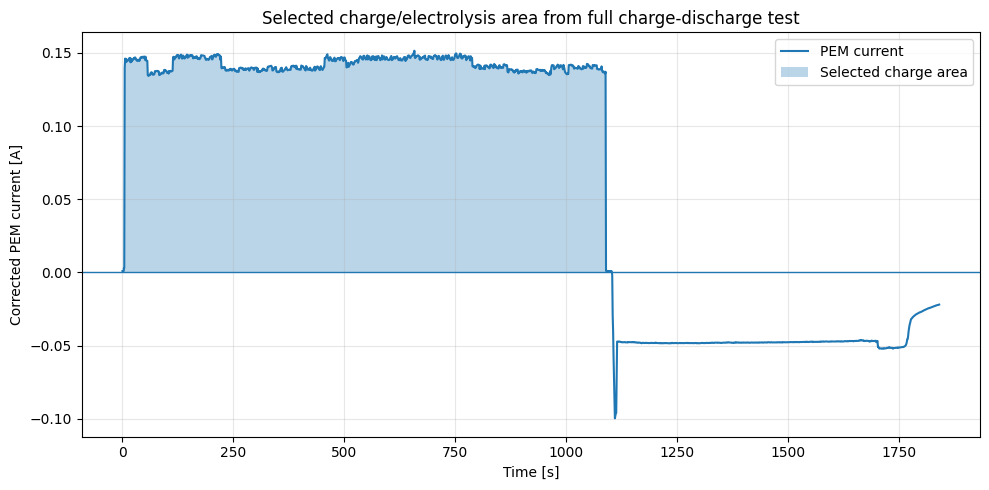

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    full_cycle["time_s"],
    full_cycle["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax.fill_between(
    full_cycle_charge["time_s"],
    full_cycle_charge["pem_current_A"],
    alpha=0.3,
    label="Selected charge area",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Corrected PEM current [A]")
ax.set_title("Selected charge/electrolysis area from full charge-discharge test")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

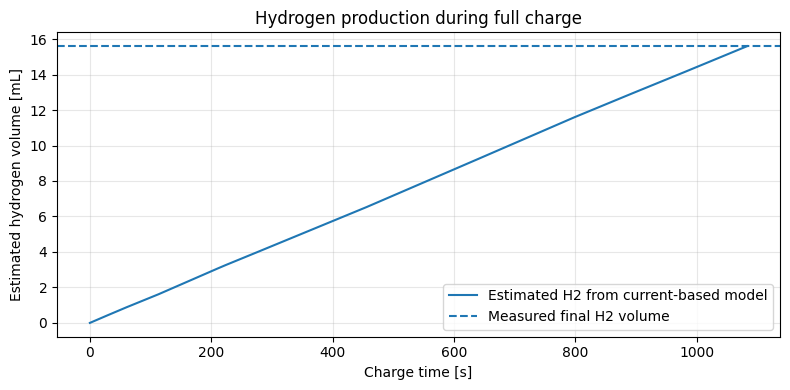

In [25]:
charge_profile = full_cycle_charge.copy()

charge_profile["cumulative_charge_C"] = cumulative_trapezoid(
    charge_profile["pem_current_A"],
    charge_profile["charge_time_s"],
)

charge_profile["estimated_H2_mL"] = (
    charge_profile["cumulative_charge_C"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
)

plt.figure(figsize=(8, 4))
plt.plot(
    charge_profile["charge_time_s"],
    charge_profile["estimated_H2_mL"],
    label="Estimated H2 from current-based model",
)

plt.axhline(
    MEASURED_FULL_HYDROGEN_CAPACITY_ML,
    linestyle="--",
    label="Measured final H2 volume",
)

plt.xlabel("Charge time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Hydrogen production during full charge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Short-test validation of the final SoH charge model

The final SoH model uses the current-based constant from the full charge-discharge test:

\[
\Delta V_{H_2} = k_{H_2,Q} \cdot I_{\mathrm{PEM}} \cdot \Delta t
\]

The short tests are used as validation if the original short-test CSV files and volume readings are available in the project folder.

In [26]:
PROJECT_ROOT = find_project_root()
readings_file = PROJECT_ROOT / "data/PEM_test/volume_readings/readings.csv"
pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"

test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

short_tests_available = readings_file.exists() and len(test_files) > 0

if short_tests_available:
    volume_readings = pd.read_csv(readings_file)
    print(f"Loaded volume readings from: {readings_file}")
    print(f"Found {len(test_files)} short-test files in: {pem_folder}")
else:
    print("Short-test validation files were not found in this environment.")
    print("When this notebook is run in the original project folder, this cell will load readings.csv and discharge_*s_r1.csv.")

Loaded volume readings from: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\volume_readings\readings.csv
Found 9 short-test files in: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\charge_discharge


Extracting content of short files

In [27]:
def parse_setpoints(file_name):
    """
    Example:
    discharge_040A_120s_r1.csv -> current = 0.40 A, duration = 120 s
    """
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s


def load_active_charge_part(file):
    """
    Load one short-test file and select only the active electrolysis section.
    Same sensor calibration and filtering as used for the full charge-discharge test.
    """
    df = pd.read_csv(file)
    df = preprocess_pem_data(df)

    charge = df[
        (df["scenario"] == 3)
        & (df["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
    ].copy()

    if charge.empty:
        raise ValueError(f"No active charge region found in {file.name}")

    charge["charge_time_s"] = (
        charge["time_s"] - charge["time_s"].iloc[0]
    )

    return charge

Calculate measured charge from each short test

In [28]:
if short_tests_available:
    rows = []

    for file in test_files:
        current_setpoint_A, duration_setpoint_s = parse_setpoints(file.name)
        charge = load_active_charge_part(file)

        input_charge_C = np.trapezoid(
            charge["pem_current_A"],
            charge["charge_time_s"],
        )

        input_energy_J = np.trapezoid(
            charge["pem_charge_power_W"],
            charge["charge_time_s"],
        )

        volume_match = volume_readings[
            (volume_readings["current_A"] == current_setpoint_A)
            & (volume_readings["time_s"] == duration_setpoint_s)
        ]

        if volume_match.empty:
            raise ValueError(
                f"No manual volume reading found for {file.name} "
                f"with current={current_setpoint_A} A and time={duration_setpoint_s} s"
            )

        measured_h2_mL = volume_match["volume_mL"].iloc[0]

        rows.append({
            "file": file.name,
            "current_setpoint_A": current_setpoint_A,
            "duration_setpoint_s": duration_setpoint_s,
            "input_charge_C": input_charge_C,
            "input_energy_J": input_energy_J,
            "measured_h2_mL": measured_h2_mL,
        })

    short_validation = (
        pd.DataFrame(rows)
        .sort_values(["current_setpoint_A", "duration_setpoint_s"])
        .reset_index(drop=True)
    )
else:
    short_validation = pd.DataFrame()
    print("Short-test validation was skipped because the original short-test files were not available.")

Validate final model on short tests

In [29]:
if short_tests_available:
    short_validation["predicted_h2_current_model_mL"] = (
        short_validation["input_charge_C"]
        * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
    )

    short_validation["predicted_h2_energy_model_mL"] = (
        short_validation["input_energy_J"]
        * HYDROGEN_PRODUCTION_ML_PER_INPUT_J
    )

    short_validation["current_model_error_mL"] = (
        short_validation["predicted_h2_current_model_mL"]
        - short_validation["measured_h2_mL"]
    )

    short_validation["current_model_error_percent"] = (
        100
        * short_validation["current_model_error_mL"]
        / short_validation["measured_h2_mL"]
    )

    short_validation["energy_model_error_mL"] = (
        short_validation["predicted_h2_energy_model_mL"]
        - short_validation["measured_h2_mL"]
    )

    short_validation["energy_model_error_percent"] = (
        100
        * short_validation["energy_model_error_mL"]
        / short_validation["measured_h2_mL"]
    )

    display(short_validation)

    mae_current = short_validation["current_model_error_mL"].abs().mean()
    rmse_current = np.sqrt(
        np.mean(short_validation["current_model_error_mL"] ** 2)
    )

    mae_energy = short_validation["energy_model_error_mL"].abs().mean()
    rmse_energy = np.sqrt(
        np.mean(short_validation["energy_model_error_mL"] ** 2)
    )

    print("Validation of final full-cycle-based model on short tests")
    print(f"Current-based model constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")
    print(f"Energy-based model constant:  {HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.5f} mL/J")
    print()
    print(f"Current-based MAE:  {mae_current:.3f} mL")
    print(f"Current-based RMSE: {rmse_current:.3f} mL")
    print(f"Energy-based MAE:   {mae_energy:.3f} mL")
    print(f"Energy-based RMSE:  {rmse_energy:.3f} mL")
else:
    print("Short-test validation was skipped because the original short-test files were not available.")

,file,current_setpoint_A,duration_setpoint_s,input_charge_C,input_energy_J,measured_h2_mL,predicted_h2_current_model_mL,predicted_h2_energy_model_mL,current_model_error_mL,current_model_error_percent,energy_model_error_mL,energy_model_error_percent
0,discharge_020A_30s_r1.csv,0.2,30,5.999188,9.006077,0.2,0.607040,0.638008,0.407040,203.520142,0.438008,219.003981
1,discharge_020A_60s_r1.csv,0.2,60,11.999715,17.891981,1.6,1.214216,1.267503,-0.385784,-24.111501,-0.332497,-20.781088
2,discharge_020A_120s_r1.csv,0.2,120,23.635624,37.502336,3.0,2.391620,2.656738,-0.608380,-20.279347,-0.343262,-11.442059
3,discharge_030A_30s_r1.csv,0.3,30,8.699213,14.539331,1.6,0.880248,1.029994,-0.719752,-44.984508,-0.570006,-35.625348
4,discharge_030A_60s_r1.csv,0.3,60,17.983571,27.872162,2.2,1.819705,1.974518,-0.380295,-17.286142,-0.225482,-10.249183
5,discharge_030A_120s_r1.csv,0.3,120,35.736867,54.424084,4.2,3.616109,3.855508,-0.583891,-13.902168,-0.344492,-8.202198
6,discharge_040A_30s_r1.csv,0.4,30,11.979283,19.302371,2.2,1.212149,1.367417,-0.987851,-44.902339,-0.832583,-37.844663
7,discharge_040A_60s_r1.csv,0.4,60,24.000747,38.133061,4.0,2.428565,2.701420,-1.571435,-39.285868,-1.298580,-32.464501
8,discharge_040A_120s_r1.csv,0.4,120,47.939512,78.259763,6.0,4.850859,5.544073,-1.149141,-19.152352,-0.455927,-7.598778


Validation of final full-cycle-based model on short tests
Current-based model constant: 0.10119 mL/C
Energy-based model constant:  0.07084 mL/J

Current-based MAE:  0.755 mL
Current-based RMSE: 0.847 mL
Energy-based MAE:   0.538 mL
Energy-based RMSE:  0.624 mL


Measured vs predicted volume

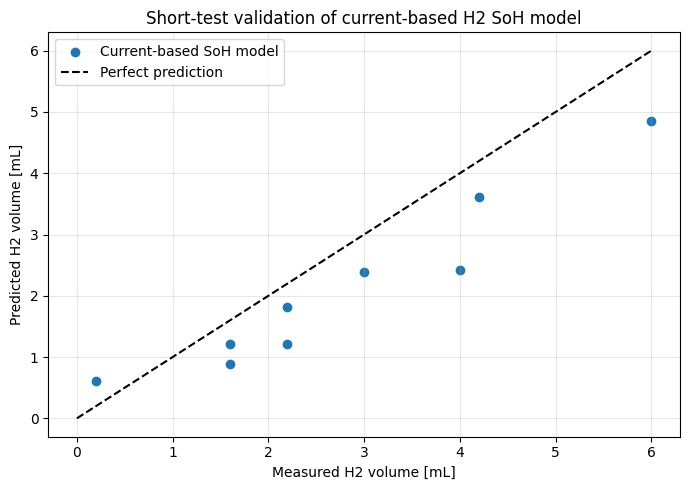

In [30]:
if short_tests_available:
    max_h2 = max(
        short_validation["measured_h2_mL"].max(),
        short_validation["predicted_h2_current_model_mL"].max(),
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        short_validation["measured_h2_mL"],
        short_validation["predicted_h2_current_model_mL"],
        label="Current-based SoH model",
    )

    plt.plot(
        [0, max_h2],
        [0, max_h2],
        linestyle="--",
        color="black",
        label="Perfect prediction",
    )

    plt.title("Short-test validation of current-based H2 SoH model")
    plt.xlabel("Measured H2 volume [mL]")
    plt.ylabel("Predicted H2 volume [mL]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Short-test validation plot was skipped because the original short-test files were not available.")

## 4. Discharge calibration from the full charge-discharge test

The active fuel-cell discharge region is selected from Scenario 6 using negative PEM current and positive corrected PEM voltage. The voltage condition avoids including the final collapsed-voltage tail as useful fuel-cell output. The current magnitude is integrated, because the measured current is negative during discharge by convention.

In [31]:
discharge_all = full_cycle[
    (full_cycle["scenario"] == 6)
    & (full_cycle["pem_current_A"] < DISCHARGE_CURRENT_THRESHOLD_A)
    & (full_cycle["pem_voltage_V"] > DISCHARGE_MIN_VOLTAGE_FOR_USEFUL_OUTPUT_V)
].copy()

if discharge_all.empty:
    raise ValueError("No active discharge region found. Check scenario labels, current threshold and voltage threshold.")

active_discharge = discharge_all.copy()

active_discharge["discharge_time_s"] = (
    active_discharge["time_s"] - active_discharge["time_s"].iloc[0]
)

active_discharge["pem_discharge_current_A"] = -active_discharge["pem_current_A"]
active_discharge["pem_discharge_power_W"] = (
    active_discharge["pem_voltage_V"].clip(lower=0)
    * active_discharge["pem_discharge_current_A"]
)

active_discharge_start_s = float(active_discharge["time_s"].iloc[0])
active_discharge_end_s = float(active_discharge["time_s"].iloc[-1])
active_discharge_duration_s = float(active_discharge["discharge_time_s"].iloc[-1])

active_output_charge_C = trapezoid_integral(
    active_discharge["pem_discharge_current_A"],
    active_discharge["discharge_time_s"],
)

active_output_energy_J = trapezoid_integral(
    active_discharge["pem_discharge_power_W"],
    active_discharge["discharge_time_s"],
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_charge_C
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_energy_J
)

HYDROGEN_DISCHARGE_RATE_ML_PER_S = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_discharge_duration_s
)

HYDROGEN_DISCHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_DISCHARGE_RATE_ML_PER_S * 60
)

round_trip_efficiency = active_output_energy_J / full_input_energy_J

discharge_results = pd.DataFrame({
    "quantity": [
        "active discharge start",
        "active discharge end",
        "active discharge duration",
        "integrated output charge",
        "integrated output energy",
        "measured H2 used",
        "H2 discharge constant",
        "H2 discharge energy constant",
        "average H2 discharge rate",
        "average H2 discharge rate",
        "round-trip efficiency estimate",
    ],
    "value": [
        active_discharge_start_s,
        active_discharge_end_s,
        active_discharge_duration_s,
        active_output_charge_C,
        active_output_energy_J,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J,
        HYDROGEN_DISCHARGE_RATE_ML_PER_S,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
        100 * round_trip_efficiency,
    ],
    "unit": [
        "s", "s", "s", "C", "J", "mL", "mL/C", "mL/J", "mL/s", "mL/min", "%"
    ],
})

display(discharge_results)

print(f"Final EMS discharge constant: {HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C:.5f} mL/C")

,quantity,value,unit
0,active discharge start,1105.000000,s
1,active discharge end,1770.000000,s
2,active discharge duration,665.000000,s
3,integrated output charge,32.262211,C
4,integrated output energy,16.867281,J
5,measured H2 used,8.000000,mL
6,H2 discharge constant,0.247968,mL/C
7,H2 discharge energy constant,0.474291,mL/J
8,average H2 discharge rate,0.012030,mL/s
9,average H2 discharge rate,0.721805,mL/min


Final EMS discharge constant: 0.24797 mL/C


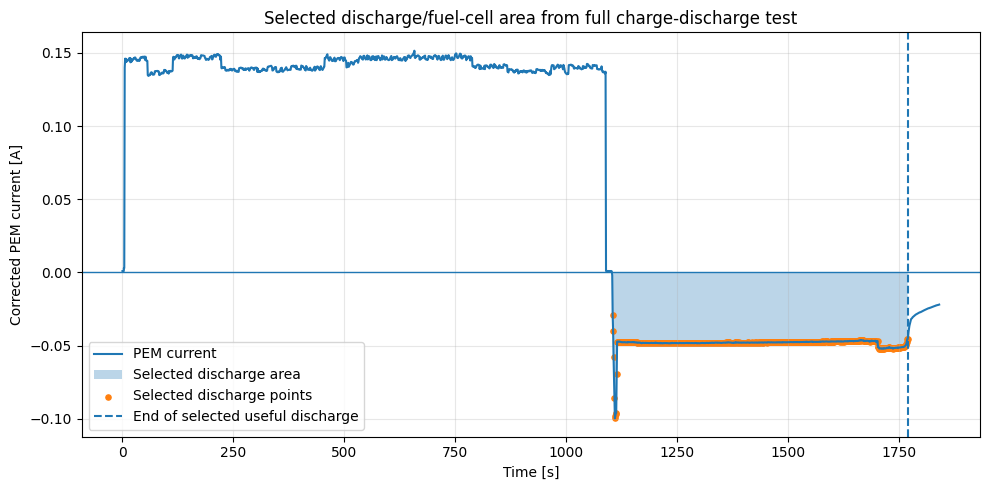

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    full_cycle["time_s"],
    full_cycle["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax.fill_between(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    0,
    alpha=0.3,
    label="Selected discharge area",
)

ax.scatter(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    s=14,
    label="Selected discharge points",
)

ax.axvline(
    active_discharge_end_s,
    linestyle="--",
    label="End of selected useful discharge",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Corrected PEM current [A]")
ax.set_title("Selected discharge/fuel-cell area from full charge-discharge test")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [33]:
discharge_sweep = full_cycle[
    full_cycle["pem_current_A"] < DISCHARGE_CURRENT_THRESHOLD_A
].copy()

lower_discharge_current_A = discharge_sweep["pem_current_A"].min()
upper_discharge_current_A = discharge_sweep["pem_current_A"].max()

print(f"Lower discharging current during test: {lower_discharge_current_A:.4f} A")
print(f"Upper discharging current during test: {upper_discharge_current_A:.4f} A")

Lower discharging current during test: -0.0997 A
Upper discharging current during test: -0.0220 A


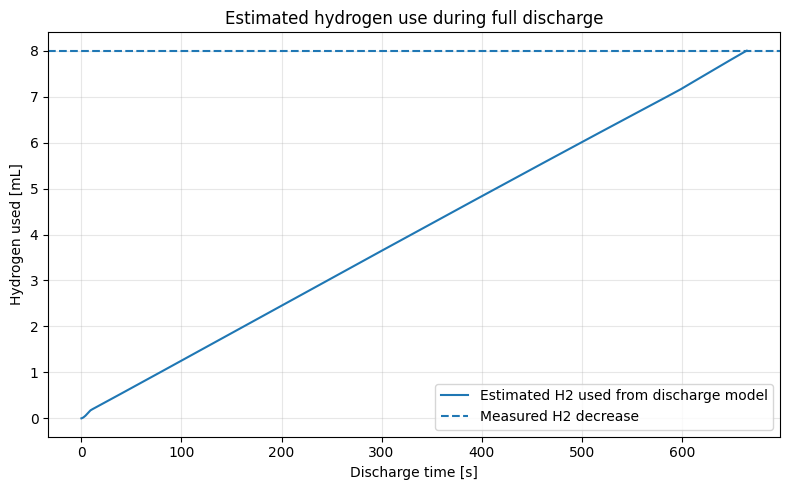

In [34]:
discharge_profile = active_discharge.copy()

cumulative_charge_C = cumulative_trapezoid(
    discharge_profile["pem_discharge_current_A"],
    discharge_profile["discharge_time_s"],
)

discharge_profile["cumulative_output_charge_C"] = cumulative_charge_C

discharge_profile["estimated_H2_used_mL"] = (
    discharge_profile["cumulative_output_charge_C"] * HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C
)

plt.figure(figsize=(8, 5))
plt.plot(
    discharge_profile["discharge_time_s"],
    discharge_profile["estimated_H2_used_mL"],
    label="Estimated H2 used from discharge model",
)

plt.axhline(
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
    linestyle="--",
    label="Measured H2 decrease",
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Hydrogen used [mL]")
plt.title("Estimated hydrogen use during full discharge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Final constants for the EMS/SoH model

The final model is current-based, so the most important constants are the `mL/C` values. The average `mL/min` rates are useful for interpretation, but they only represent the average behaviour during the selected calibration intervals.

In [35]:
ems_parameters = pd.DataFrame({
    "parameter": [
        "H2_MAX_ML",
        "H2_MIN_USABLE_ML",
        "H2_USABLE_ML",
        "HYDROGEN_PRODUCTION_ML_PER_INPUT_C",
        "HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C",
        "HYDROGEN_CHARGE_RATE_ML_PER_MIN",
        "HYDROGEN_DISCHARGE_RATE_ML_PER_MIN",
        "CHARGE_CURRENT_THRESHOLD_A",
        "DISCHARGE_CURRENT_THRESHOLD_A",
        "ROUND_TRIP_EFFICIENCY_ESTIMATE",
    ],
    "value": [
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
        CHARGE_CURRENT_THRESHOLD_A,
        DISCHARGE_CURRENT_THRESHOLD_A,
        round_trip_efficiency,
    ],
    "unit": [
        "mL", "mL", "mL", "mL/C", "mL/C", "mL/min", "mL/min", "A", "A", "-",
    ],
    "meaning": [
        "Measured full hydrogen capacity",
        "Measured remaining hydrogen after full discharge",
        "Usable hydrogen window",
        "Final charge constant from full charge test",
        "Final discharge constant from full discharge test",
        "Average charge rate during selected full charge interval",
        "Average discharge rate during selected full discharge interval",
        "Minimum current used to identify active electrolysis",
        "Maximum negative current threshold used to identify active discharge",
        "Electrical energy out divided by electrical energy in for selected full cycle",
    ],
})

display(ems_parameters)

,parameter,value,unit,meaning
0,H2_MAX_ML,15.600000,mL,Measured full hydrogen capacity
1,H2_MIN_USABLE_ML,7.600000,mL,Measured remaining hydrogen after full discharge
2,H2_USABLE_ML,8.000000,mL,Usable hydrogen window
3,HYDROGEN_PRODUCTION_ML_PER_INPUT_C,0.101187,mL/C,Final charge constant from full charge test
4,HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,0.247968,mL/C,Final discharge constant from full discharge test
5,HYDROGEN_CHARGE_RATE_ML_PER_MIN,0.864266,mL/min,Average charge rate during selected full charg...
6,HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,0.721805,mL/min,Average discharge rate during selected full di...
7,CHARGE_CURRENT_THRESHOLD_A,0.050000,A,Minimum current used to identify active electr...
8,DISCHARGE_CURRENT_THRESHOLD_A,-0.005000,A,Maximum negative current threshold used to ide...
9,ROUND_TRIP_EFFICIENCY_ESTIMATE,0.076597,-,Electrical energy out divided by electrical en...



h2_charge_mL_per_C: float = 0.104095
h2_discharge_mL_per_C: float = 0.25175648

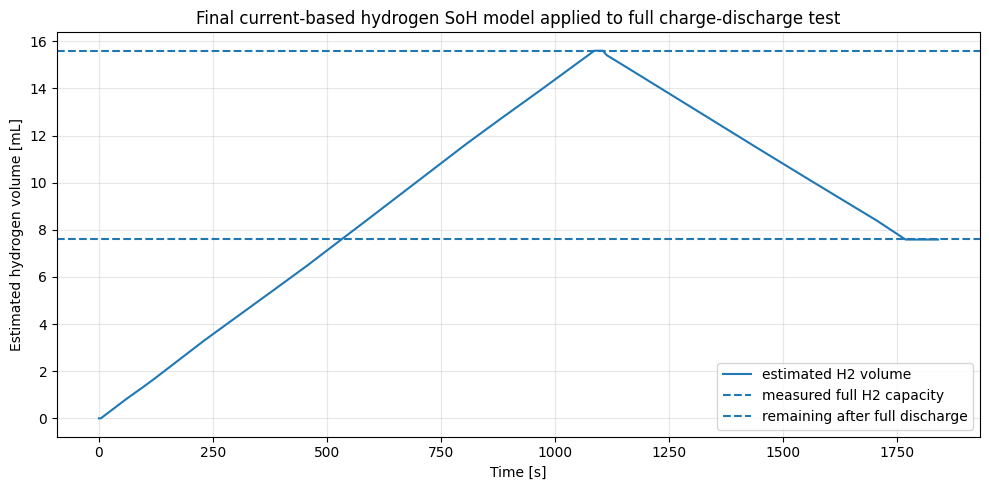

,timestamp,scenario,mode,time_s,pem_current_A,estimated_h2_mL,usable_soh_percent
1737,2026-04-30 13:44:11,6,Scenario 6: PEM -> Load,1831.0,-0.022962,7.5874,0.0
1738,2026-04-30 13:44:12,6,Scenario 6: PEM -> Load,1832.0,-0.022815,7.5874,0.0
1739,2026-04-30 13:44:13,6,Scenario 6: PEM -> Load,1833.0,-0.022752,7.5874,0.0
1740,2026-04-30 13:44:14,6,Scenario 6: PEM -> Load,1834.0,-0.022562,7.5874,0.0
1741,2026-04-30 13:44:15,6,Scenario 6: PEM -> Load,1835.0,-0.022541,7.5874,0.0
1742,2026-04-30 13:44:16,6,Scenario 6: PEM -> Load,1836.0,-0.022414,7.5874,0.0
1743,2026-04-30 13:44:18,6,Scenario 6: PEM -> Load,1838.0,-0.022309,7.5874,0.0
1744,2026-04-30 13:44:19,6,Scenario 6: PEM -> Load,1839.0,-0.022204,7.5874,0.0
1745,2026-04-30 13:44:20,6,Scenario 6: PEM -> Load,1840.0,-0.022077,7.5874,0.0
1746,2026-04-30 13:44:21,6,Scenario 6: PEM -> Load,1841.0,-0.021993,7.5874,0.0


In [36]:
def estimate_h2_profile_from_current(
    df: pd.DataFrame,
    initial_h2_mL: float = 0.0,
    h2_min_mL: float = 0.0,
    h2_max_mL: float = MEASURED_FULL_HYDROGEN_CAPACITY_ML,
) -> pd.DataFrame:
    """
    Apply the final current-based H2 SoH model to a measured PEM current profile.
    Positive current charges the H2 storage; negative current discharges it.
    """
    out = df.copy()
    out["dt_s"] = out["time_s"].diff().fillna(0)

    h2_values = []
    h2_mL = initial_h2_mL

    for _, row in out.iterrows():
        I = row["pem_current_A"]
        V = row["pem_voltage_V"]
        dt_s = row["dt_s"]

        if I > CHARGE_CURRENT_THRESHOLD_A:
            h2_mL += HYDROGEN_PRODUCTION_ML_PER_INPUT_C * I * dt_s

        elif I < DISCHARGE_CURRENT_THRESHOLD_A and V > DISCHARGE_MIN_VOLTAGE_FOR_USEFUL_OUTPUT_V:
            h2_mL -= HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C * abs(I) * dt_s

        h2_mL = min(max(h2_mL, h2_min_mL), h2_max_mL)
        h2_values.append(h2_mL)

    out["estimated_h2_mL"] = h2_values
    out["usable_soh"] = (
        (out["estimated_h2_mL"] - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML)
        / MEASURED_USABLE_HYDROGEN_DISCHARGE_ML
    ).clip(0, 1)

    out["usable_soh_percent"] = 100 * out["usable_soh"]

    return out


soh_profile = estimate_h2_profile_from_current(
    full_cycle,
    initial_h2_mL=0.0,
    h2_min_mL=0.0,
    h2_max_mL=MEASURED_FULL_HYDROGEN_CAPACITY_ML,
)

plt.figure(figsize=(10, 5))
plt.plot(
    soh_profile["time_s"],
    soh_profile["estimated_h2_mL"],
    label="estimated H2 volume",
)

plt.axhline(MEASURED_FULL_HYDROGEN_CAPACITY_ML, linestyle="--", label="measured full H2 capacity")
plt.axhline(MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML, linestyle="--", label="remaining after full discharge")

plt.xlabel("Time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Final current-based hydrogen SoH model applied to full charge-discharge test")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(
    soh_profile[
        ["timestamp", "scenario", "mode", "time_s", "pem_current_A", "estimated_h2_mL", "usable_soh_percent"]
    ].tail(10)
)

## Interpretation

The final EMS/SoH model should use the current-based constants:

\[
k_{H_2,\mathrm{charge}} = \mathrm{HYDROGEN\_PRODUCTION\_ML\_PER\_INPUT\_C}
\]

\[
k_{H_2,\mathrm{discharge}} = \mathrm{HYDROGEN\_DISCHARGE\_ML\_PER\_OUTPUT\_C}
\]

The charge constant is based on the selected full Scenario 3 electrolysis interval. The discharge constant is based on the selected full Scenario 6 fuel-cell interval with positive corrected PEM voltage.

The short tests are used only as validation, because their manual volume readings are small and therefore relatively noisy.

### Round trip effeciency 

because the discharge test did not utilise all hydrogen, the round trip effeciency takes this into account, by estimating how much energy was used in electrolysis to produce the 8mL that was only possible to discharge in fuel cell mode

In [40]:
# Round-trip efficiency estimate when discharge only used part of the produced hydrogen

electrolysis_input_energy_J = full_input_energy_J
fuel_cell_output_energy_J = active_output_energy_J

measured_h2_produced_mL = MEASURED_FULL_HYDROGEN_CAPACITY_ML
measured_h2_used_mL = 8.0

h2_fraction_used = measured_h2_used_mL / measured_h2_produced_mL

apparent_round_trip_efficiency = (
    fuel_cell_output_energy_J / electrolysis_input_energy_J
)

electrolysis_input_energy_for_used_h2_J = (
    electrolysis_input_energy_J * h2_fraction_used
)

h2_normalised_round_trip_efficiency = (
    fuel_cell_output_energy_J / electrolysis_input_energy_for_used_h2_J
)

round_trip_results = pd.DataFrame({
    "quantity": [
        "electrolysis input energy for full charge",
        "fuel-cell output energy from discharge",
        "H2 produced during charge",
        "H2 used during discharge",
        "fraction of produced H2 used",
        "apparent round-trip efficiency",
        "input energy corresponding to used H2",
        "H2-normalised partial round-trip efficiency",
    ],
    "value": [
        electrolysis_input_energy_J,
        fuel_cell_output_energy_J,
        measured_h2_produced_mL,
        measured_h2_used_mL,
        100 * h2_fraction_used,
        100 * apparent_round_trip_efficiency,
        electrolysis_input_energy_for_used_h2_J,
        100 * h2_normalised_round_trip_efficiency,
    ],
    "unit": [
        "J",
        "J",
        "mL",
        "mL",
        "%",
        "%",
        "J",
        "%",
    ],
})

display(round_trip_results)

print("Round-trip efficiency estimate")
print(f"Electrolysis input energy for full charge:   {electrolysis_input_energy_J:.2f} J")
print(f"Fuel-cell output energy from discharge:      {fuel_cell_output_energy_J:.2f} J")
print(f"H2 produced during charge:                   {measured_h2_produced_mL:.2f} mL")
print(f"H2 used during discharge:                    {measured_h2_used_mL:.2f} mL")
print(f"Fraction of produced H2 used:                {100 * h2_fraction_used:.2f} %")
print()
print(f"Apparent round-trip efficiency:              {100 * apparent_round_trip_efficiency:.2f} %")
print(f"Input energy corresponding to used H2:       {electrolysis_input_energy_for_used_h2_J:.2f} J")
print(f"H2-normalised partial round-trip efficiency: {100 * h2_normalised_round_trip_efficiency:.2f} %")

,quantity,value,unit
0,electrolysis input energy for full charge,220.208540,J
1,fuel-cell output energy from discharge,16.867281,J
2,H2 produced during charge,15.600000,mL
3,H2 used during discharge,8.000000,mL
4,fraction of produced H2 used,51.282051,%
5,apparent round-trip efficiency,7.659685,%
6,input energy corresponding to used H2,112.927457,J
7,H2-normalised partial round-trip efficiency,14.936386,%


Round-trip efficiency estimate
Electrolysis input energy for full charge:   220.21 J
Fuel-cell output energy from discharge:      16.87 J
H2 produced during charge:                   15.60 mL
H2 used during discharge:                    8.00 mL
Fraction of produced H2 used:                51.28 %

Apparent round-trip efficiency:              7.66 %
Input energy corresponding to used H2:       112.93 J
H2-normalised partial round-trip efficiency: 14.94 %
